# ANN Word2Vec Benchmark
Train and evaluate the ANN baseline using skip-gram Word2Vec embeddings with mean pooling.

In [1]:
from pathlib import Path
import sys
import yaml
import torch
from gensim.models import Word2Vec
from IPython.display import Image, display
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.trainer import train_baseline, build_model, prepare_ann_dataloaders, resolve_device
from src.utils import load_config, plot_confusion_matrix, plot_metrics_bar, plot_training_curves

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'experiment.yaml'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figure' / '02_training'
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


/home/coronny/sentiment_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/coronny/sentiment_analysis/.venv/lib/python3.13/site-packages/pyvi/ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


## 1) Train Word2Vec ANN baseline

In [2]:
history = train_baseline(str(CONFIG_PATH))
config = load_config(CONFIG_PATH)
model_name = config['models']['model_name'].lower()
feature_type = config['features']['type']
assert feature_type == 'word2vec', f'Expected word2vec features, got {feature_type}'
feature_tag = 'w2vec'
benchmark_name = f'{model_name}_{feature_tag}'

history_path = OUTPUTS_DIR / f'{benchmark_name}_history.yaml'
if history_path.exists():
    with open(history_path, 'r', encoding='utf-8') as f:
        history = yaml.safe_load(f)

history


---Đang tải datasets UIT ---


Saving the dataset (1/1 shards): 100%|██████████| 3166/3166 [00:00<00:00, 467132.18 examples/s]


Đã tải xong! Train: 11426 câu.
Epoch 1/50 | Train Loss: 0.9985 | Val Loss: 0.8185 | Train Acc: 0.5109 | Val Acc: 0.8313
Epoch 2/50 | Train Loss: 0.7518 | Val Loss: 0.7196 | Train Acc: 0.8297 | Val Acc: 0.8484
Epoch 3/50 | Train Loss: 0.6910 | Val Loss: 0.6907 | Train Acc: 0.8440 | Val Acc: 0.8604
Epoch 4/50 | Train Loss: 0.6663 | Val Loss: 0.6736 | Train Acc: 0.8489 | Val Acc: 0.8629
Epoch 5/50 | Train Loss: 0.6462 | Val Loss: 0.6588 | Train Acc: 0.8477 | Val Acc: 0.8604
Epoch 6/50 | Train Loss: 0.6347 | Val Loss: 0.6487 | Train Acc: 0.8437 | Val Acc: 0.8604
Epoch 7/50 | Train Loss: 0.6173 | Val Loss: 0.6385 | Train Acc: 0.8480 | Val Acc: 0.8604
Epoch 8/50 | Train Loss: 0.6075 | Val Loss: 0.6319 | Train Acc: 0.8429 | Val Acc: 0.8591
Epoch 9/50 | Train Loss: 0.5927 | Val Loss: 0.6252 | Train Acc: 0.8475 | Val Acc: 0.8636
Epoch 10/50 | Train Loss: 0.5930 | Val Loss: 0.6171 | Train Acc: 0.8455 | Val Acc: 0.8585
Epoch 11/50 | Train Loss: 0.5851 | Val Loss: 0.6156 | Train Acc: 0.8422 | Val 

{'train_loss': [0.9985155106922767,
  0.7518154112153879,
  0.6909762566815542,
  0.6663029383680674,
  0.6462072234330231,
  0.634684750071451,
  0.6173272117889127,
  0.6074601940227954,
  0.5926650706782687,
  0.5929967216085955,
  0.5850641180932855,
  0.5710067573789112,
  0.5666184592679893,
  0.565077775808353,
  0.5557146114843518,
  0.54321103913491,
  0.5450919958341388,
  0.5393398303392879,
  0.5329154674067843,
  0.528633249392889,
  0.5199348491163893,
  0.5230825270770648,
  0.5150898514346703,
  0.5088476229812846,
  0.5017736383490057,
  0.5045155425394714,
  0.4999561072561328,
  0.505011670208177,
  0.4996274079940173,
  0.5002165194080529,
  0.4800301818125075,
  0.4870621157425076,
  0.48660704472710964,
  0.481537780198971,
  0.4753542431323222,
  0.47534784608047104,
  0.4720195370450533,
  0.465806605346376,
  0.46610248604966276,
  0.4637186204463077,
  0.4582231653718975,
  0.45561898849363436,
  0.45214370414406563,
  0.4601579578853519,
  0.4644819364867397,

## 2) Plot training curves

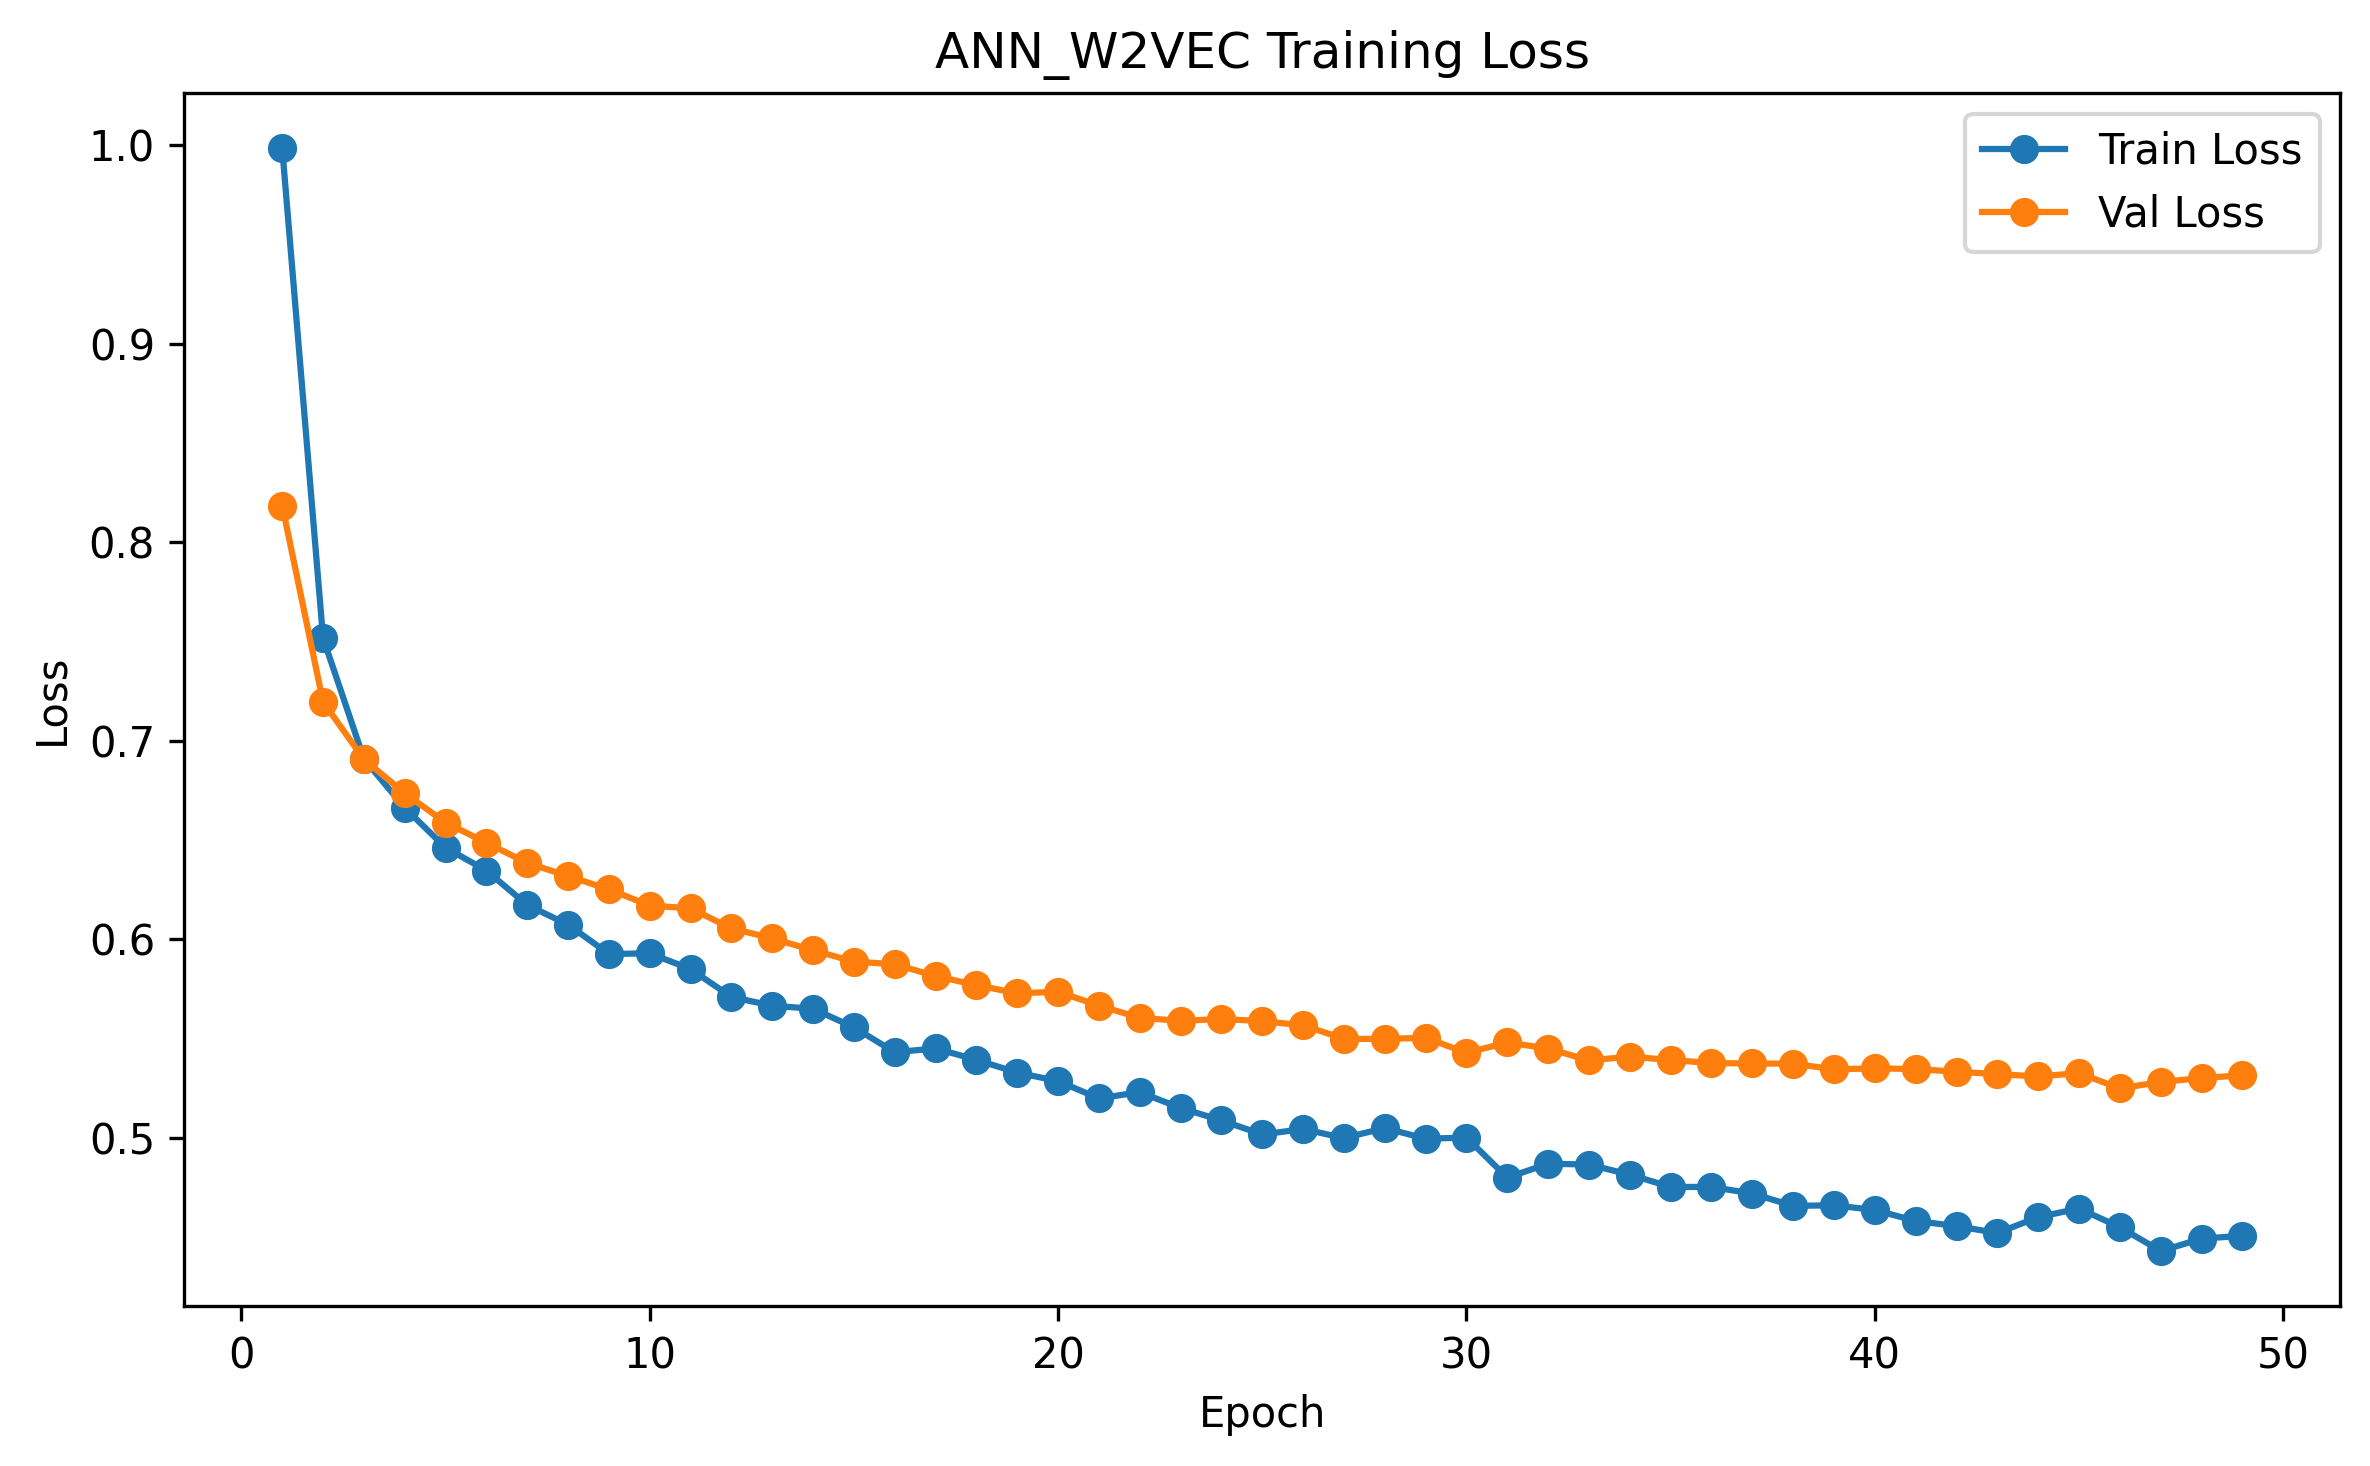

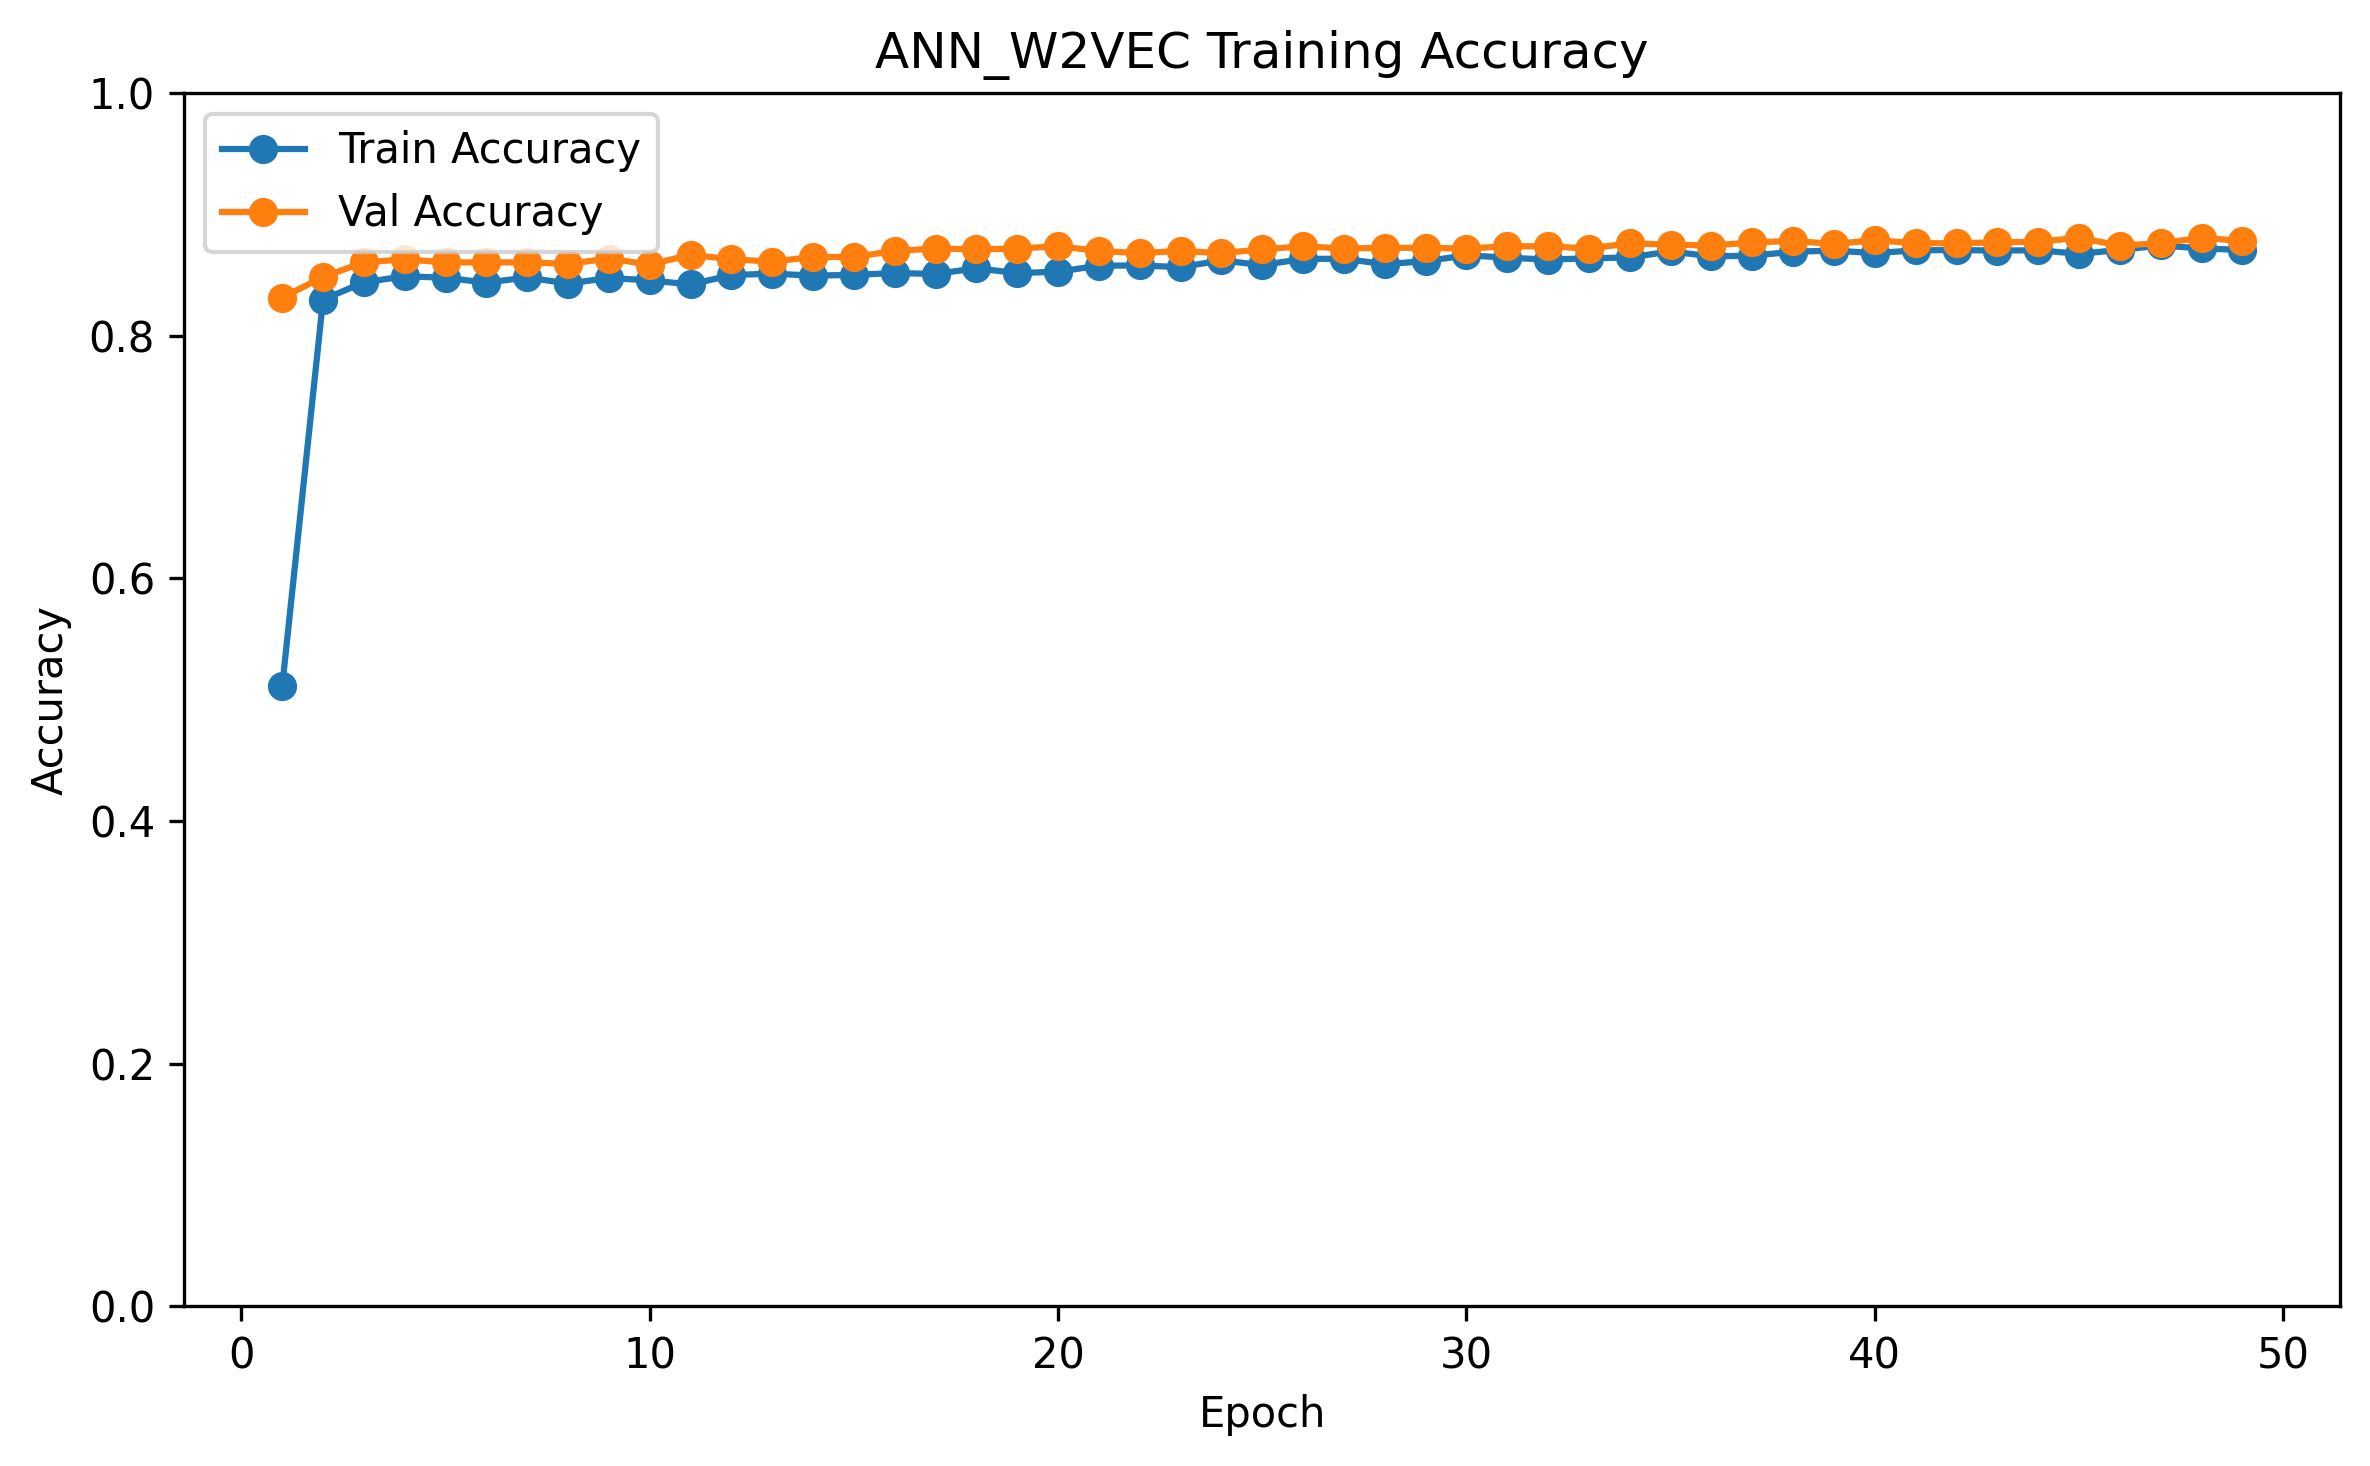

{'loss': PosixPath('/home/coronny/sentiment_analysis/reports/figure/02_training/ann_w2vec_feature100_dropout0_3_loss.png'),
 'accuracy': PosixPath('/home/coronny/sentiment_analysis/reports/figure/02_training/ann_w2vec_feature100_dropout0_3_accuracy.png')}

In [3]:
vector_size = config['features']['word2vec']['vector_size']
curve_paths = plot_training_curves(
    history=history,
    model_name=benchmark_name,
    max_features=vector_size,
    dropout=config['models']['ann']['dropout'],
    output_dir=OUTPUT_FIGURE_DIR,
)
display(Image(filename=str(curve_paths['loss'])))
display(Image(filename=str(curve_paths['accuracy'])))
curve_paths


## 3) Evaluate best checkpoint on validation set

In [4]:
device = resolve_device(config['training']['device'])
word2vec_path = MODELS_DIR / f'{benchmark_name}_word2vec_model.model'
word2vec_model = Word2Vec.load(str(word2vec_path))

_, val_loader, _ = prepare_ann_dataloaders(config, feature_encoder=word2vec_model)
model = build_model(config).to(device)
best_ckpt_path = CHECKPOINTS_DIR / f'{benchmark_name}_best_model.pt'
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_true, all_pred = [], []
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.extend(preds.tolist())
        all_true.extend(y_batch.cpu().numpy().tolist())

acc = accuracy_score(all_true, all_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_true,
    all_pred,
    average='macro',
    zero_division=0,
)
metrics = {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}
metrics


---Đang tải datasets UIT ---


Saving the dataset (1/1 shards): 100%|██████████| 3166/3166 [00:00<00:00, 489951.90 examples/s]


Đã tải xong! Train: 11426 câu.


{'accuracy': 0.8742893240682249,
 'precision': 0.7236354354998422,
 'recall': 0.7798551710251939,
 'f1': 0.7418375927509556}

## 4) Plot confusion matrix

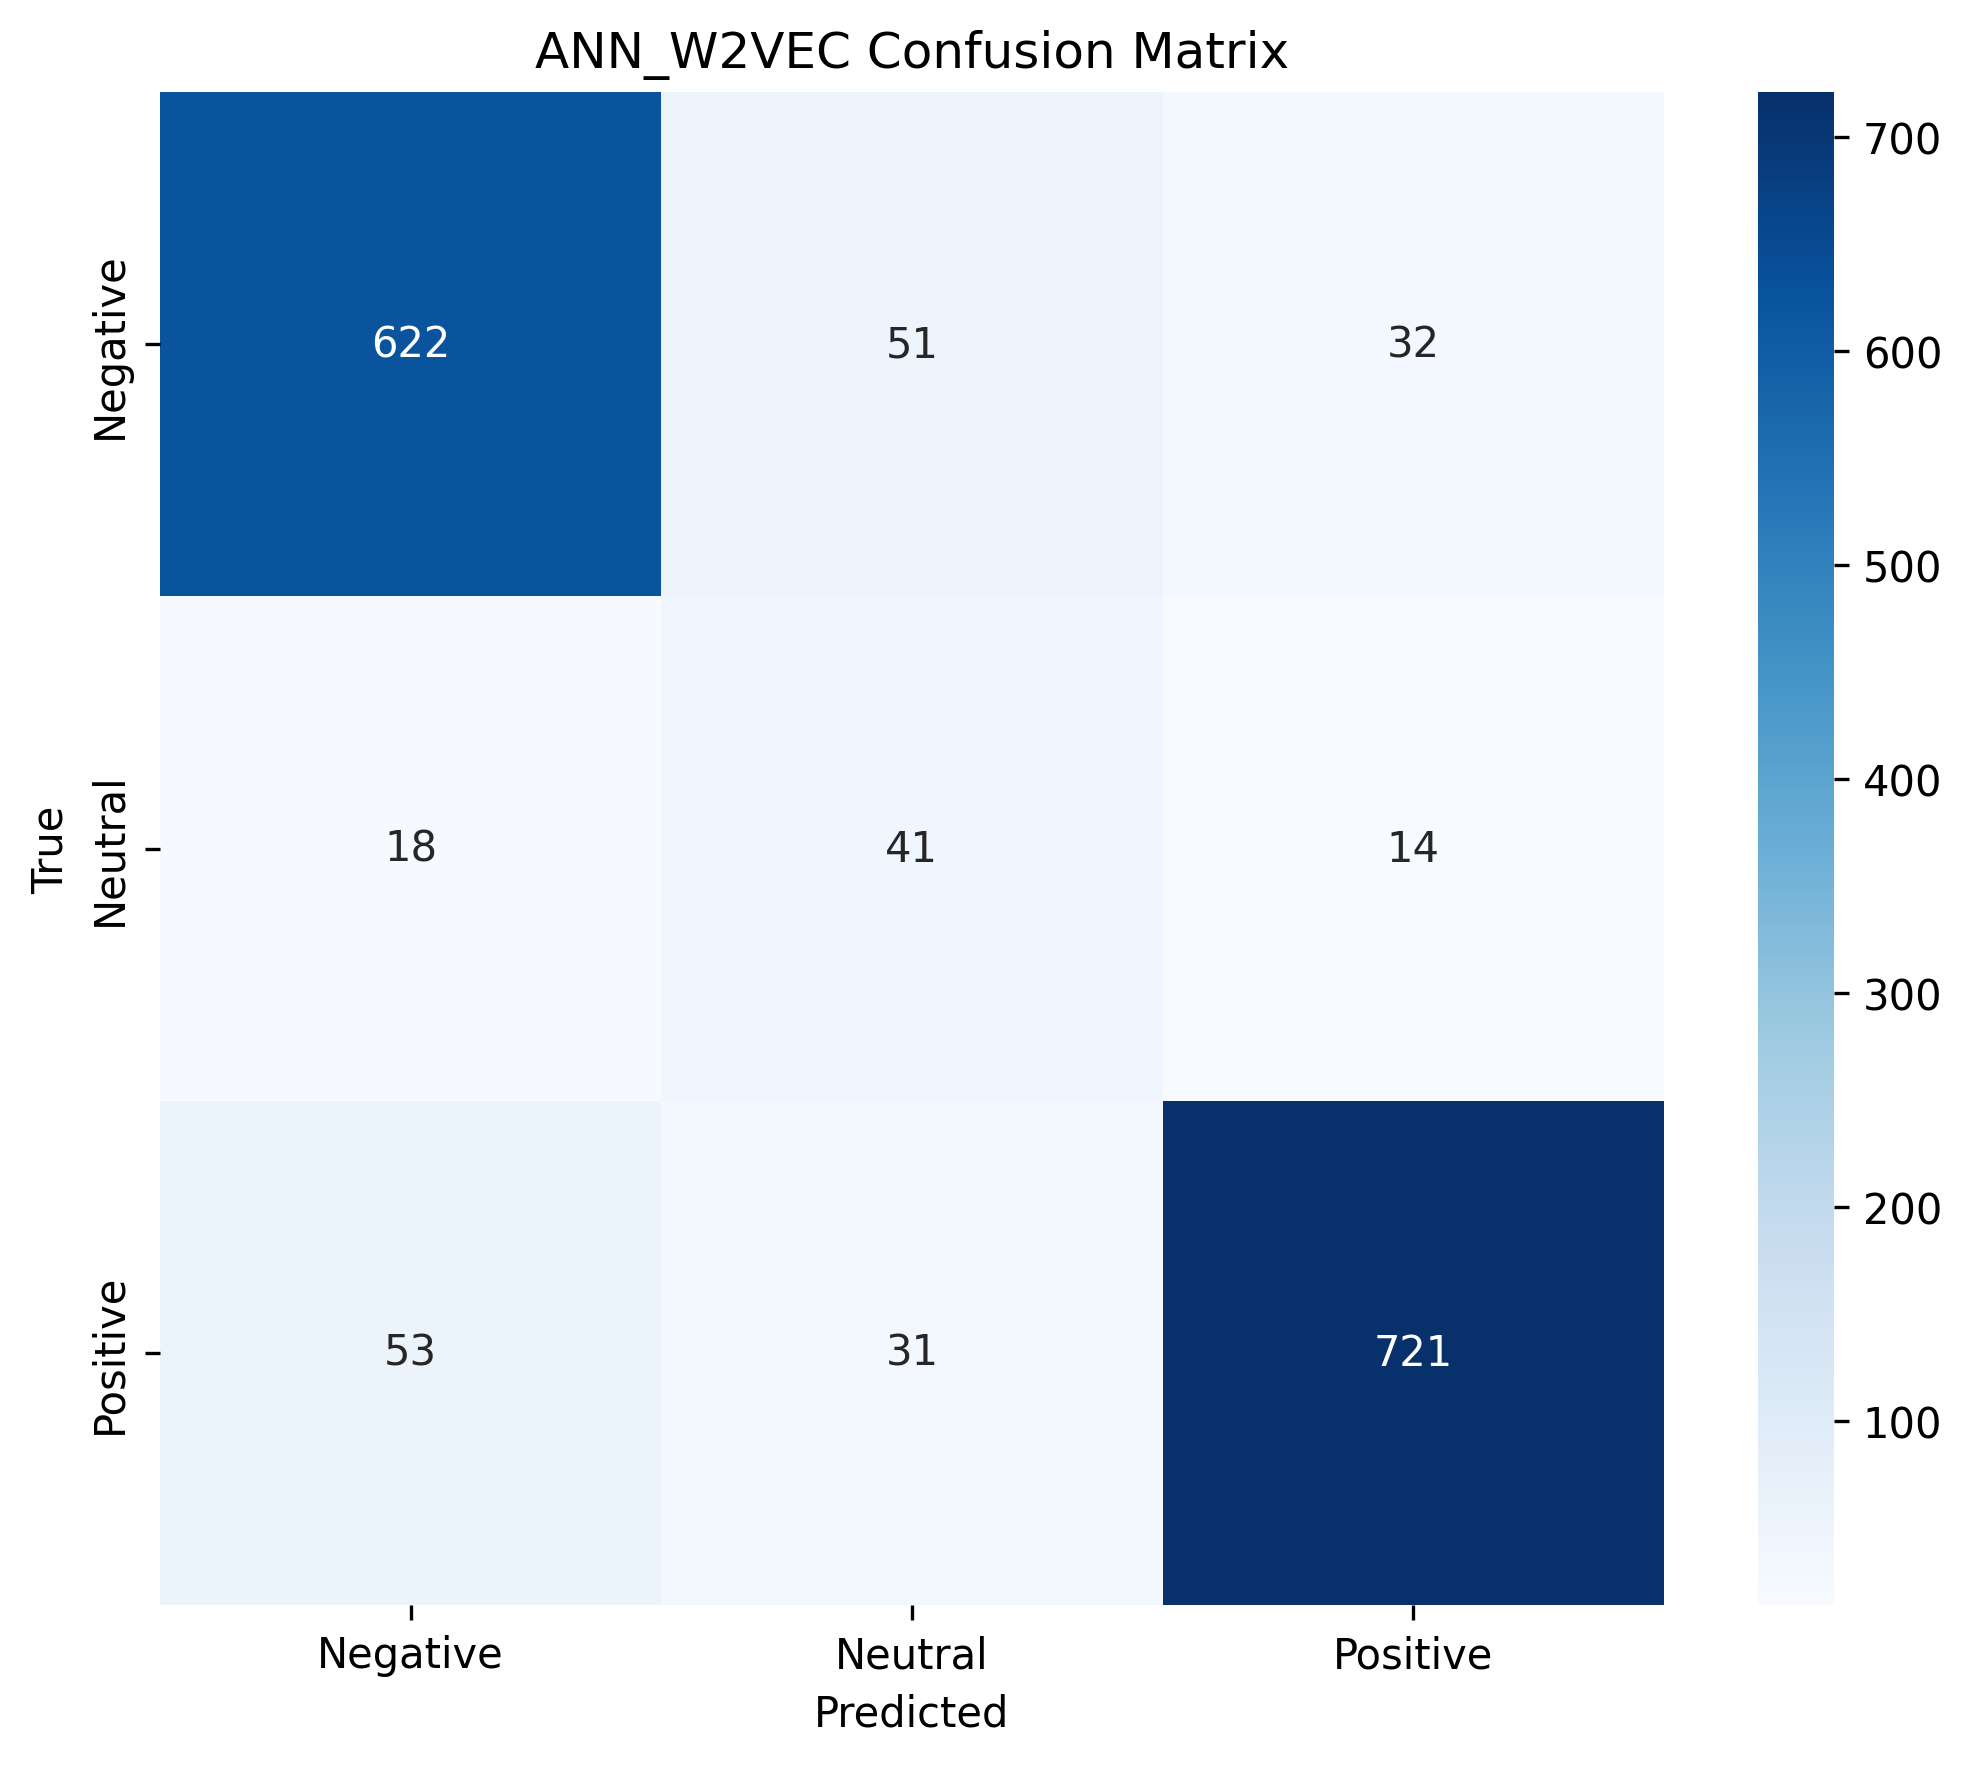

PosixPath('/home/coronny/sentiment_analysis/reports/figure/02_training/ann_w2vec_confusion_matrix.png')

In [5]:
label_names = ['Negative', 'Neutral', 'Positive']
cm_path = plot_confusion_matrix(
    y_true=all_true,
    y_pred=all_pred,
    labels=label_names,
    model_name=benchmark_name,
    output_dir=OUTPUT_FIGURE_DIR,
)
display(Image(filename=str(cm_path)))
cm_path


## 5) Plot benchmark metrics

/home/coronny/sentiment_analysis/src/utils.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metric_names, y=metric_values, palette="viridis")


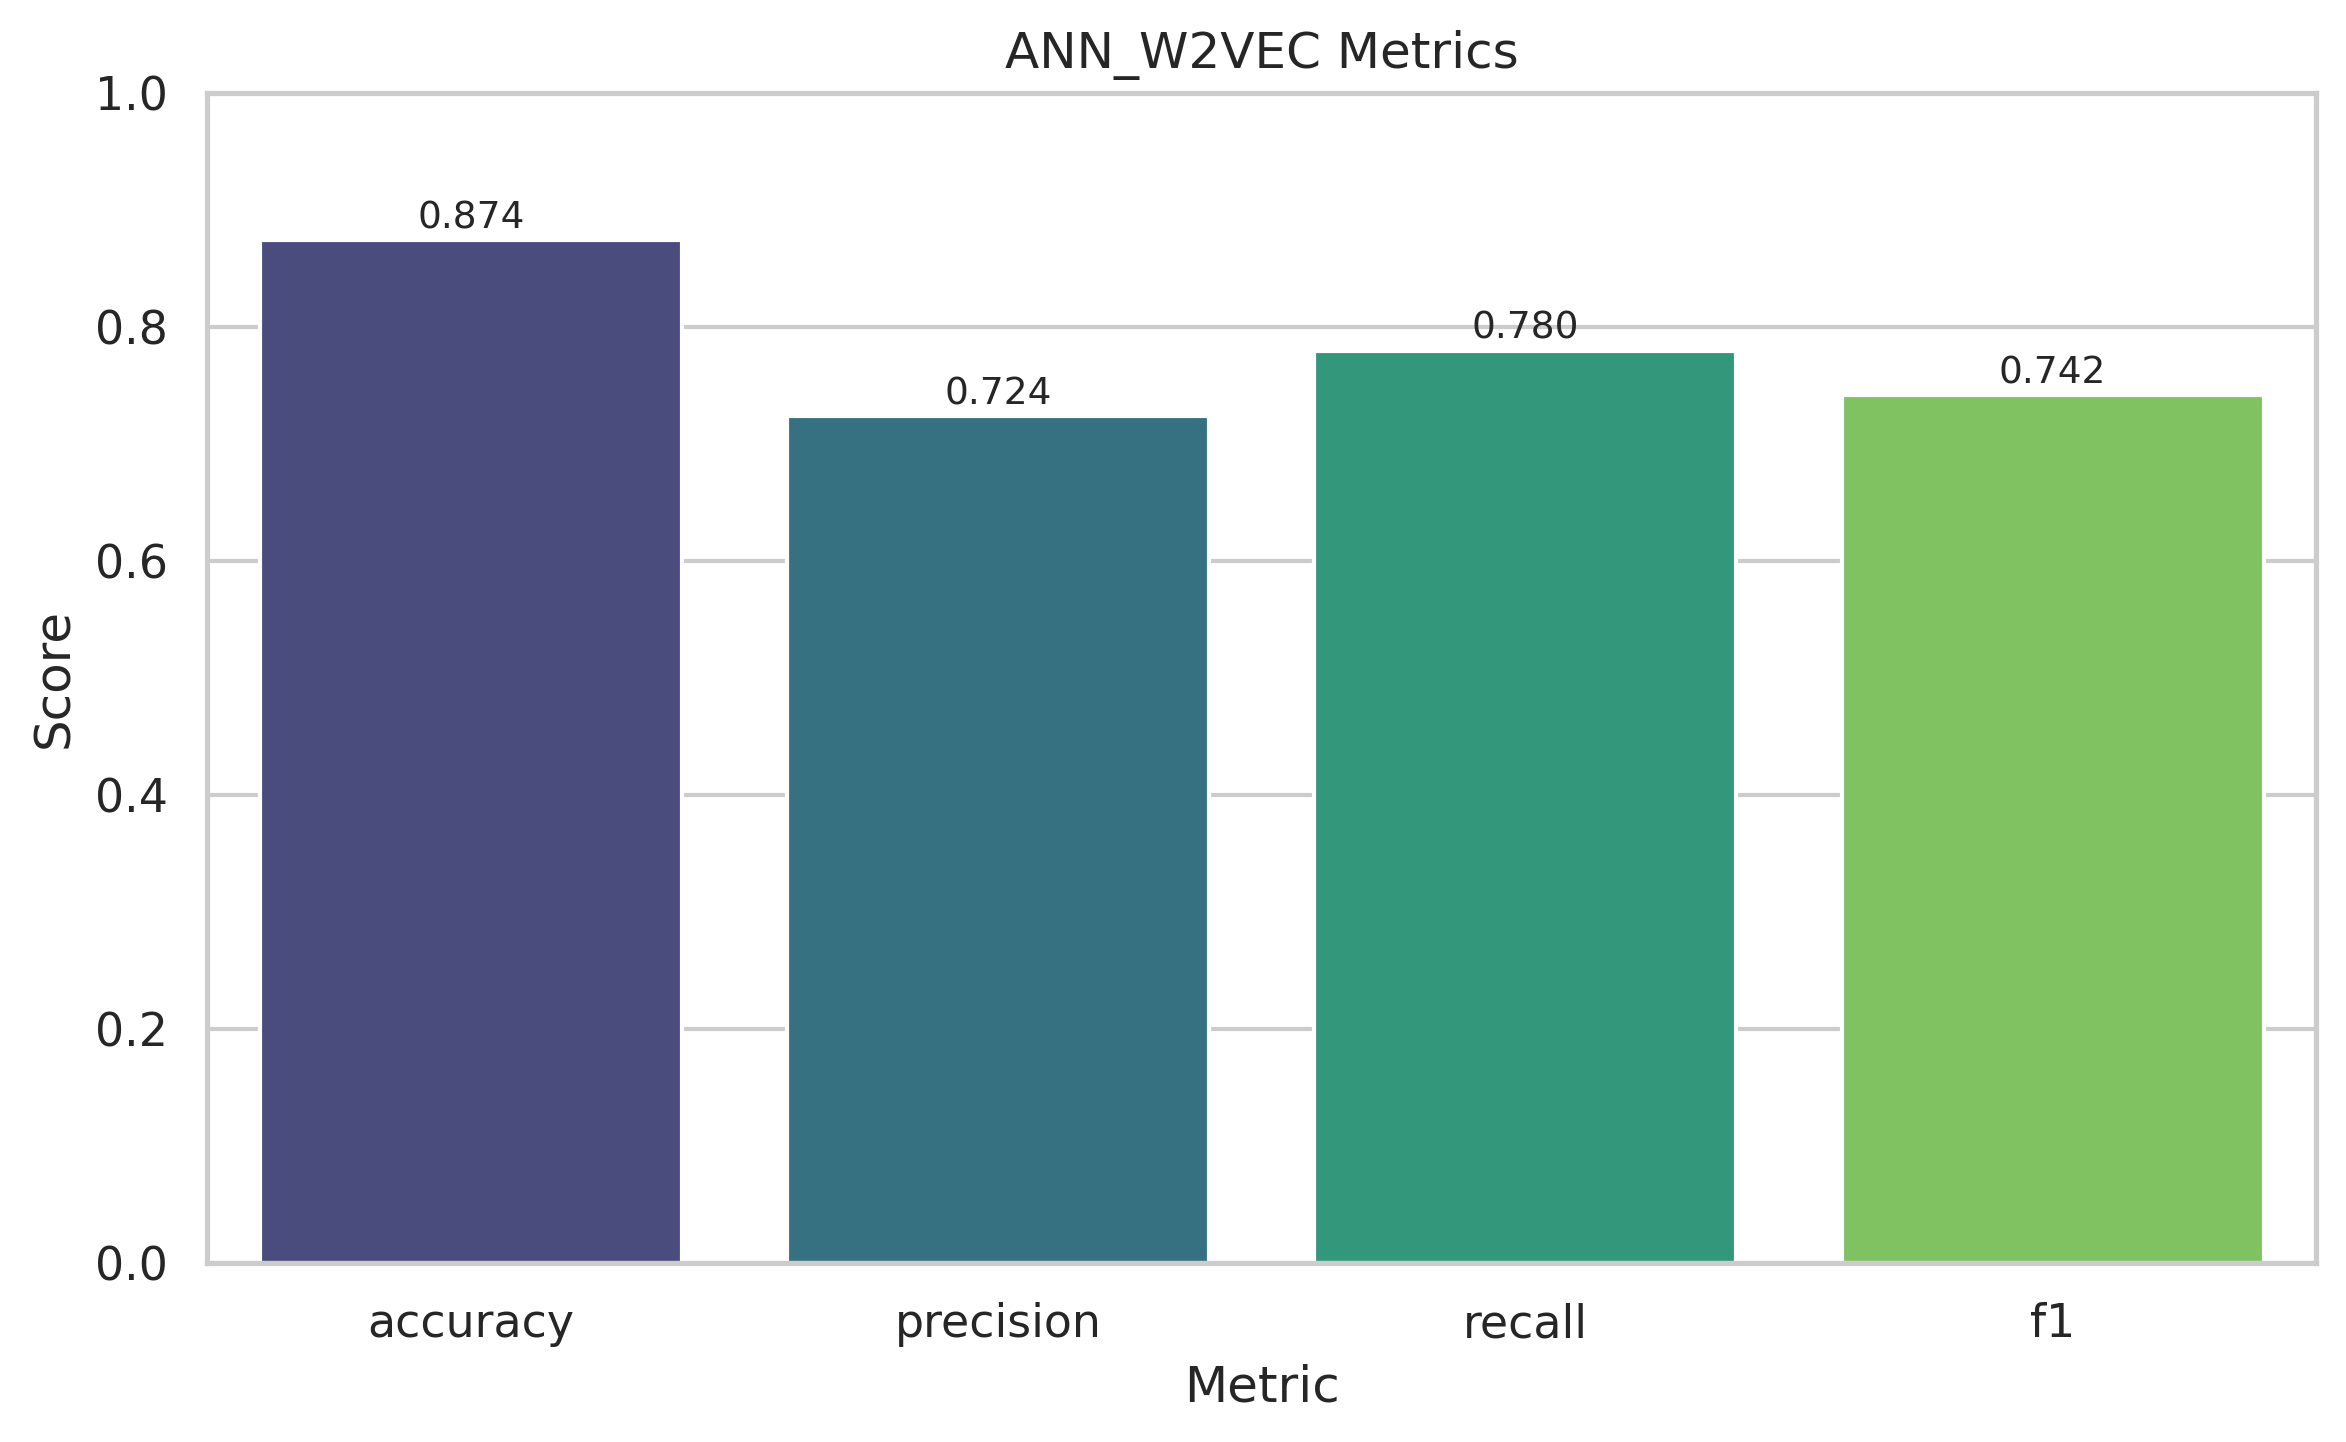

PosixPath('/home/coronny/sentiment_analysis/reports/figure/02_training/ann_w2vec_metrics.png')

In [6]:
metric_path = plot_metrics_bar(
    metrics=metrics,
    model_name=benchmark_name,
    metric_group_name='metrics',
    output_dir=OUTPUT_FIGURE_DIR,
)
display(Image(filename=str(metric_path)))
metric_path
